In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q timm kagglehub

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "div456/indian-saree-patterns"
)

print("Dataset path:", dataset_path)

Dataset path: /kaggle/input/datasets/div456/indian-saree-patterns


In [2]:
import os

dataset_path = "/kaggle/input/datasets/div456/indian-saree-patterns"

print("Dataset contents:\n")

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:10]:
        print(f"{indent}  {file}")

Dataset contents:

indian-saree-patterns/
  README.dataset.txt
  README.roboflow.txt
  valid/
    Banarasi/
    Pichwai/
    Bandhani/
    Ikat/
  test/
    Banarasi/
    Pichwai/
    Bandhani/
    Ikat/
  train/
    Banarasi/
    Pichwai/
    Bandhani/
    Ikat/


In [6]:
import os

dataset_path = "/kaggle/input/datasets/div456/indian-saree-patterns"

for split in ["train", "valid", "test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n{split.upper()}")
    print("-" * 30)

    total = 0

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ])

            print(f"{class_name:12s}: {count}")
            total += count

    print(f"TOTAL        : {total}")


TRAIN
------------------------------
Banarasi    : 432
Bandhani    : 279
Ikat        : 303
Pichwai     : 279
TOTAL        : 1293

VALID
------------------------------
Banarasi    : 43
Bandhani    : 22
Ikat        : 26
Pichwai     : 24
TOTAL        : 115

TEST
------------------------------
Banarasi    : 14
Bandhani    : 15
Ikat        : 13
Pichwai     : 18
TOTAL        : 60


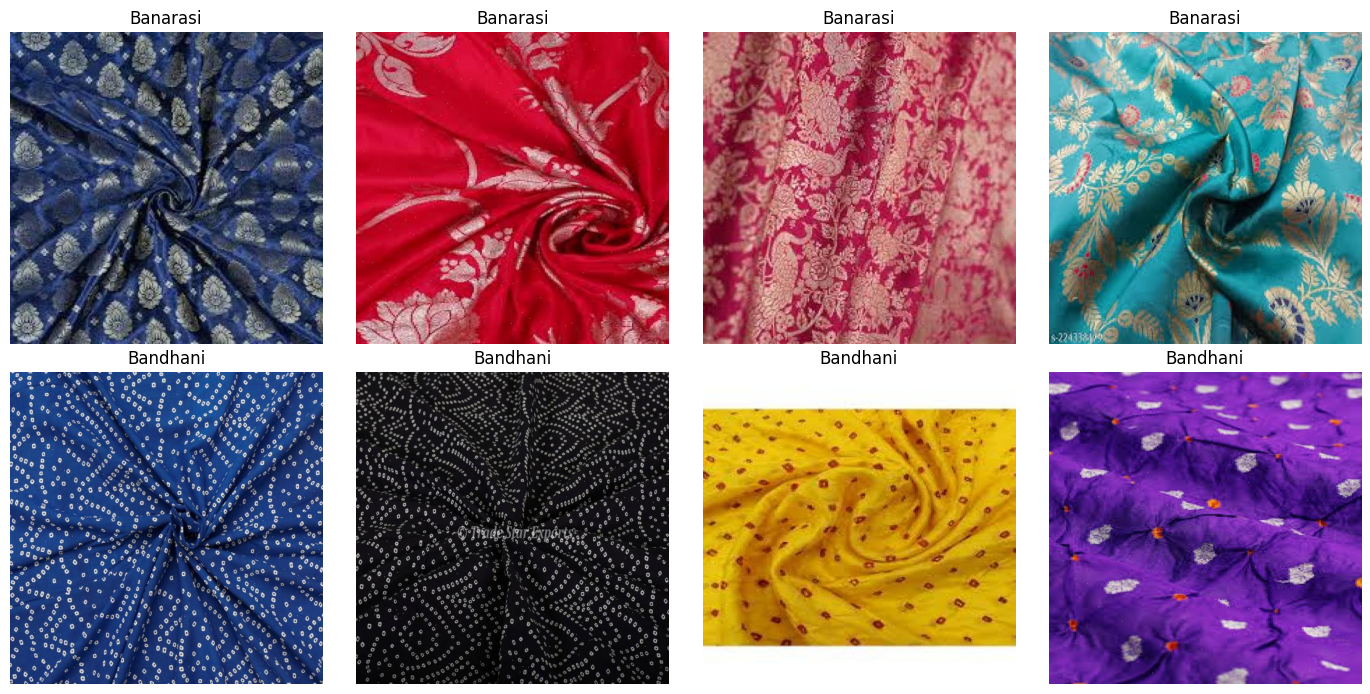

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

train_path = "/kaggle/input/datasets/div456/indian-saree-patterns/train"

classes = ["Banarasi", "Bandhani", "Ikat", "Pichwai"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, class_name in enumerate(classes[:2]):
    class_path = os.path.join(train_path, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    for col in range(4):
        img_file = random.choice(images)
        img_path = os.path.join(class_path, img_file)

        img = Image.open(img_path).convert("RGB")

        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Important for color-invariant learning
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.35,
        contrast=0.30,
        saturation=0.60,
        hue=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [12]:
train_path = "/kaggle/input/datasets/div456/indian-saree-patterns/train"
valid_path = "/kaggle/input/datasets/div456/indian-saree-patterns/valid"
test_path  = "/kaggle/input/datasets/div456/indian-saree-patterns/test"

train_dataset = datasets.ImageFolder(
    train_path,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    valid_path,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    test_path,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))
print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Classes: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']
Number of classes: 4
Train: 1293
Validation: 115
Test: 60


In [13]:
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

# Replace the final classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)

print("ResNet50 loaded.")
print("Embedding dimension:", num_features)
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


ResNet50 loaded.
Embedding dimension: 2048
Device: cuda


In [15]:
from copy import deepcopy
import time

# Calculate class weights to handle mild class imbalance
class_counts = np.bincount(train_dataset.targets)
class_weights = len(train_dataset) / (len(class_counts) * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

best_val_acc = 0.0
best_state = None
patience = 2
epochs_without_improvement = 0

NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Learning-rate scheduler
    scheduler.step(val_acc)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    # Best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())

        torch.save(
            best_state,
            "/kaggle/working/best_saree_resnet50.pth"
        )

        epochs_without_improvement = 0

        print("  ✓ Best model saved.")

    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:

        print("  Early stopping triggered.")
        break


# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch [1/5] | Train Loss: 0.8836 | Train Acc: 0.7309 | Val Loss: 0.4417 | Val Acc: 0.8609 | Time: 15.4s
  ✓ Best model saved.
Epoch [2/5] | Train Loss: 0.1909 | Train Acc: 0.9474 | Val Loss: 0.1912 | Val Acc: 0.9652 | Time: 13.3s
  ✓ Best model saved.
Epoch [3/5] | Train Loss: 0.0752 | Train Acc: 0.9822 | Val Loss: 0.1442 | Val Acc: 0.9391 | Time: 13.5s
Epoch [4/5] | Train Loss: 0.0434 | Train Acc: 0.9923 | Val Loss: 0.1638 | Val Acc: 0.9304 | Time: 13.6s
  Early stopping triggered.

Training complete.
Best validation accuracy: 0.9652


Test Accuracy: 0.9500
Test Accuracy: 95.00%

Classification Report:

              precision    recall  f1-score   support

    Banarasi     0.9231    0.8571    0.8889        14
    Bandhani     0.8824    1.0000    0.9375        15
        Ikat     1.0000    1.0000    1.0000        13
     Pichwai     1.0000    0.9444    0.9714        18

    accuracy                         0.9500        60
   macro avg     0.9514    0.9504    0.9495        60
weighted avg     0.9526    0.9500    0.9499        60



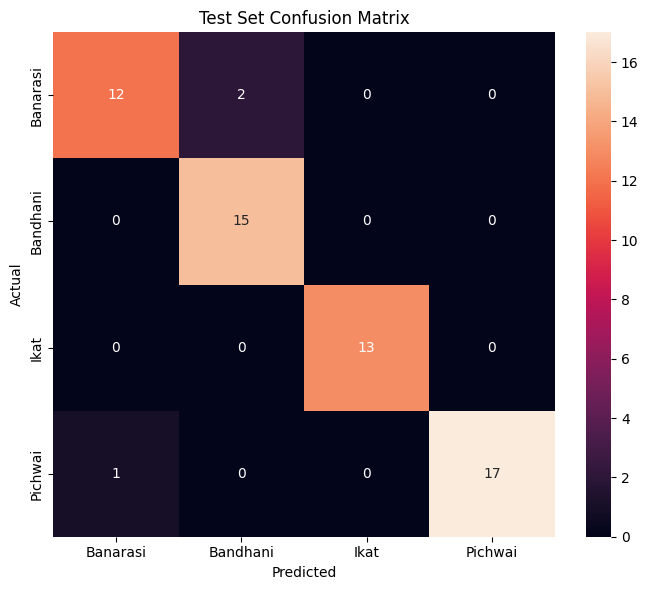

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
# Create an embedding model from the trained ResNet50

embedding_model = models.resnet50(weights=None)

# Remove the final classification layer
embedding_model.fc = nn.Identity()

# Load our best trained weights
full_model = models.resnet50(weights=None)
full_model.fc = nn.Linear(2048, 4)

full_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_saree_resnet50.pth",
        map_location=device
    )
)

# Copy the trained feature extractor
embedding_model = full_model
embedding_model.fc = nn.Identity()

embedding_model = embedding_model.to(device)
embedding_model.eval()

print("Embedding model ready.")
print("Embedding size: 2048")

Embedding model ready.
Embedding size: 2048


In [18]:
import torch.nn.functional as F

def extract_embeddings(model, loader):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for images, batch_labels in loader:
            images = images.to(device)

            features = model(images)

            # L2-normalize embeddings
            features = F.normalize(features, p=2, dim=1)

            embeddings.append(features.cpu())
            labels.append(batch_labels)

    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    return embeddings, labels


# Gallery = training images
gallery_embeddings, gallery_labels = extract_embeddings(
    embedding_model,
    train_loader
)

# Query = unseen test images
query_embeddings, query_labels = extract_embeddings(
    embedding_model,
    test_loader
)

print("Gallery embeddings:", gallery_embeddings.shape)
print("Query embeddings:", query_embeddings.shape)

Gallery embeddings: torch.Size([1293, 2048])
Query embeddings: torch.Size([60, 2048])


In [19]:
def retrieval_accuracy(
    query_embeddings,
    query_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=1
):
    similarities = query_embeddings @ gallery_embeddings.T

    top_indices = torch.topk(
        similarities,
        k=top_k,
        dim=1
    ).indices

    correct = 0

    for i in range(len(query_labels)):
        retrieved_labels = gallery_labels[top_indices[i]]

        if query_labels[i] in retrieved_labels:
            correct += 1

    return correct / len(query_labels)


top1 = retrieval_accuracy(
    query_embeddings,
    query_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=1
)

top3 = retrieval_accuracy(
    query_embeddings,
    query_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=3
)

top5 = retrieval_accuracy(
    query_embeddings,
    query_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=5
)

print(f"Top-1 Retrieval Accuracy: {top1 * 100:.2f}%")
print(f"Top-3 Retrieval Accuracy: {top3 * 100:.2f}%")
print(f"Top-5 Retrieval Accuracy: {top5 * 100:.2f}%")

Top-1 Retrieval Accuracy: 93.33%
Top-3 Retrieval Accuracy: 93.33%
Top-5 Retrieval Accuracy: 95.00%


In [21]:
color_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ColorJitter(
        brightness=0.40,
        contrast=0.35,
        saturation=0.80,
        hue=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Color-invariance transform ready.")

Color-invariance transform ready.


In [22]:
original_test_dataset = datasets.ImageFolder(
    test_path,
    transform=eval_transform
)

color_test_dataset = datasets.ImageFolder(
    test_path,
    transform=color_transform
)

original_test_loader = DataLoader(
    original_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

color_test_loader = DataLoader(
    color_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Original test images:", len(original_test_dataset))
print("Color-altered test images:", len(color_test_dataset))

Original test images: 60
Color-altered test images: 60


In [23]:
original_embeddings, original_labels = extract_embeddings(
    embedding_model,
    original_test_loader
)

color_embeddings, color_labels = extract_embeddings(
    embedding_model,
    color_test_loader
)

# Cosine similarity because embeddings are normalized
pairwise_similarity = torch.sum(
    original_embeddings * color_embeddings,
    dim=1
)

print(
    f"Mean cosine similarity: "
    f"{pairwise_similarity.mean().item():.4f}"
)

print(
    f"Minimum cosine similarity: "
    f"{pairwise_similarity.min().item():.4f}"
)

print(
    f"Maximum cosine similarity: "
    f"{pairwise_similarity.max().item():.4f}"
)

Mean cosine similarity: 0.8657
Minimum cosine similarity: 0.3212
Maximum cosine similarity: 0.9903


In [25]:
color_top1 = retrieval_accuracy(
    color_embeddings,
    color_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=1
)

color_top3 = retrieval_accuracy(
    color_embeddings,
    color_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=3
)

color_top5 = retrieval_accuracy(
    color_embeddings,
    color_labels,
    gallery_embeddings,
    gallery_labels,
    top_k=5
)

print(f"Color-altered Top-1: {color_top1 * 100:.2f}%")
print(f"Color-altered Top-3: {color_top3 * 100:.2f}%")
print(f"Color-altered Top-5: {color_top5 * 100:.2f}%")

Color-altered Top-1: 95.00%
Color-altered Top-3: 95.00%
Color-altered Top-5: 95.00%


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Convert labels to numpy
orig_labels = original_labels.numpy()
color_labels_np = color_labels.numpy()

# --------------------------------------------------
# Positive pairs:
# original image ↔ its own color-altered version
# --------------------------------------------------

positive_scores = torch.sum(
    original_embeddings * color_embeddings,
    dim=1
).numpy()

# --------------------------------------------------
# Negative pairs:
# original image ↔ color-altered image
# from a DIFFERENT class
# --------------------------------------------------

negative_indices = []

for i in range(len(orig_labels)):

    # Find indices belonging to a different class
    candidates = np.where(
        color_labels_np != orig_labels[i]
    )[0]

    # Deterministic selection
    selected = candidates[i % len(candidates)]

    negative_indices.append(selected)

negative_indices = np.array(negative_indices)

negative_color_embeddings = color_embeddings[
    negative_indices
]

negative_scores = torch.sum(
    original_embeddings * negative_color_embeddings,
    dim=1
).numpy()

# --------------------------------------------------
# Combine scores
# --------------------------------------------------

scores = np.concatenate([
    positive_scores,
    negative_scores
])

labels = np.concatenate([
    np.ones(len(positive_scores)),
    np.zeros(len(negative_scores))
])

# ROC-AUC
auc = roc_auc_score(labels, scores)

# ROC curve
fpr, tpr, thresholds = roc_curve(labels, scores)

# Youden's J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold = thresholds[best_idx]

# Predictions
predictions = (
    scores >= best_threshold
).astype(int)

# Metrics
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions)
recall = recall_score(labels, predictions)
f1 = f1_score(labels, predictions)

print("Corrected Verification Results")
print("=" * 45)

print(f"ROC-AUC   : {auc:.4f}")
print(f"Threshold : {best_threshold:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Corrected Verification Results
ROC-AUC   : 0.9994
Threshold : 0.5932
Accuracy  : 0.9917
Precision : 1.0000
Recall    : 0.9833
F1 Score  : 0.9916


In [29]:
# Model parameter count

total_params = sum(
    p.numel()
    for p in full_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in full_model.parameters()
    if p.requires_grad
)

model_size_mb = total_params * 4 / (1024 ** 2)

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Approx. FP32 size     : {model_size_mb:.2f} MB")
print(f"Embedding dimension   : 2048")

Total parameters      : 23,508,032
Trainable parameters  : 23,508,032
Approx. FP32 size     : 89.68 MB
Embedding dimension   : 2048


In [30]:
print("=" * 60)
print("DEEP LURE - COLOR-INVARIANT SAREE DESIGN RECOGNITION")
print("=" * 60)

print("\nMODEL")
print("Architecture          : ResNet50")
print("Embedding dimension   : 2048")
print("Parameters            : 23,508,032")
print("Model size (FP32)     : 89.68 MB")

print("\nCLASSIFICATION")
print(f"Best Validation Acc   : {best_val_acc * 100:.2f}%")
print(f"Test Accuracy         : {test_accuracy * 100:.2f}%")

print("\nIDENTIFICATION")
print(f"Top-1 Retrieval       : {top1 * 100:.2f}%")
print(f"Top-3 Retrieval       : {top3 * 100:.2f}%")
print(f"Top-5 Retrieval       : {top5 * 100:.2f}%")

print("\nCOLOR-INVARIANT RETRIEVAL")
print(f"Top-1                 : {color_top1 * 100:.2f}%")
print(f"Top-3                 : {color_top3 * 100:.2f}%")
print(f"Top-5                 : {color_top5 * 100:.2f}%")

print("\nVERIFICATION")
print(f"ROC-AUC               : {auc * 100:.2f}%")
print(f"Accuracy              : {accuracy * 100:.2f}%")
print(f"Precision             : {precision * 100:.2f}%")
print(f"Recall                : {recall * 100:.2f}%")
print(f"F1 Score              : {f1 * 100:.2f}%")
print(f"Threshold             : {best_threshold:.4f}")

print("\n" + "=" * 60)

DEEP LURE - COLOR-INVARIANT SAREE DESIGN RECOGNITION

MODEL
Architecture          : ResNet50
Embedding dimension   : 2048
Parameters            : 23,508,032
Model size (FP32)     : 89.68 MB

CLASSIFICATION
Best Validation Acc   : 96.52%
Test Accuracy         : 95.00%

IDENTIFICATION
Top-1 Retrieval       : 93.33%
Top-3 Retrieval       : 93.33%
Top-5 Retrieval       : 95.00%

COLOR-INVARIANT RETRIEVAL
Top-1                 : 95.00%
Top-3                 : 95.00%
Top-5                 : 95.00%

VERIFICATION
ROC-AUC               : 99.94%
Accuracy              : 99.17%
Precision             : 100.00%
Recall                : 98.33%
F1 Score              : 99.16%
Threshold             : 0.5932

